In [ ]:
import pandas as pd

In [2]:
df = pd.read_csv("Electronic_sales_Sep2023-Sep2024.csv")

1. На основании датасета получите доход:
    * по каждому методу доставки, 
    * по каждому типу продукта, 
    * по дополнительным услугам за каждый месяц,
    * по дополнительным услугам за каждый квартал. 


In [ ]:
# 1. Доход по методу доставки
ship_method = df[['Shipping Type', 'Total Price']].groupby('Shipping Type').sum().reset_index()

# 2. Доход по типу продукта
product_type = df[['Product Type', 'Total Price']].groupby('Product Type').sum().reset_index()

# 3. Дополнительные услуги за каждый месяц
df['month'] = pd.to_datetime(df['Purchase Date']).dt.to_period('M')
addons_month = df.groupby('month')['Add-on Total'].sum().reset_index()

# 4. Дополнительные услуги за каждый квартал
df['quarter'] = pd.to_datetime(df['Purchase Date']).dt.to_period('Q')
addons_quarter = df.groupby('quarter')['Add-on Total'].sum().reset_index()

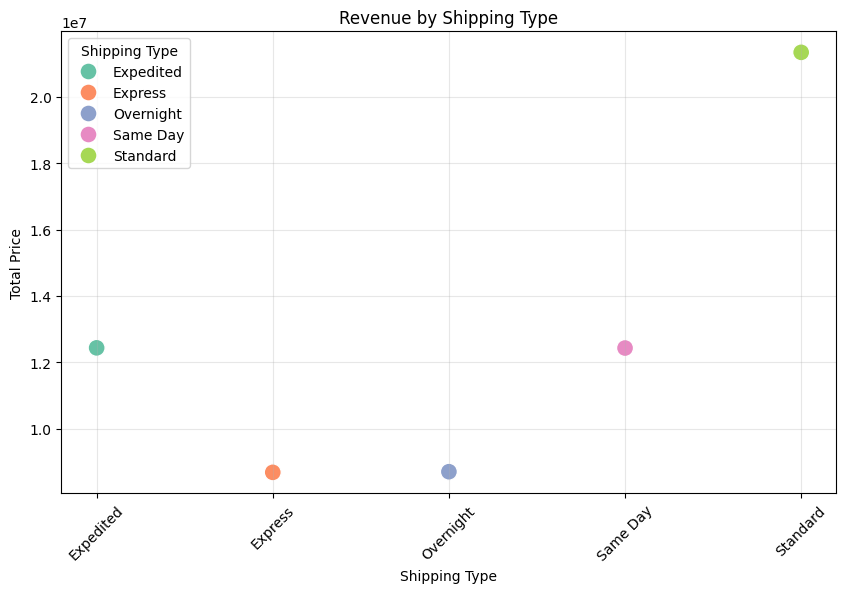

In [30]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=ship_method,
    x='Shipping Type',
    y='Total Price',
    hue='Shipping Type',
    s=150,
    palette='Set2'
)

plt.title('Revenue by Shipping Type')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

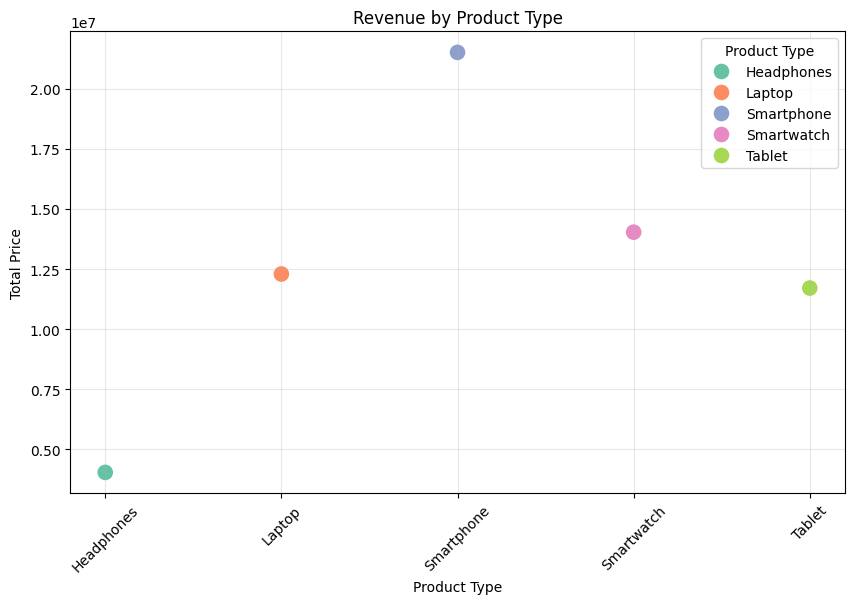

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=product_type,
    x='Product Type',
    y='Total Price',
    hue='Product Type',
    s=150,
    palette='Set2'
)

plt.title('Revenue by Product Type')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=addons_month,
    x='Product Type',
    y='Total Price',
    hue='Product Type',
    s=150,
    palette='Set2'
)

plt.title('Revenue by Product Type')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

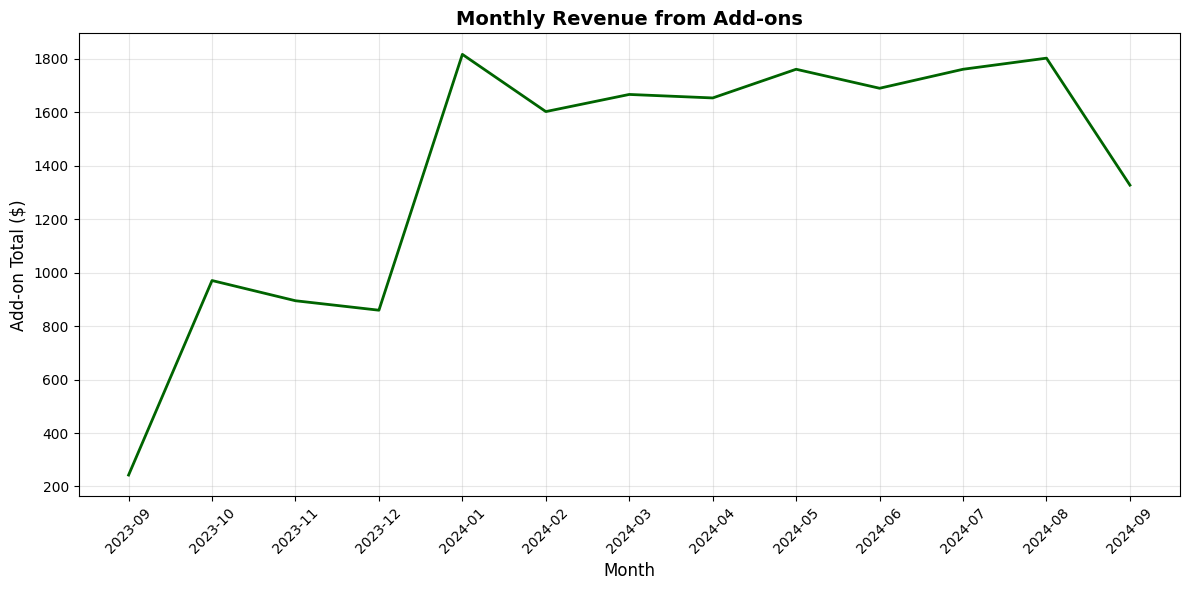

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

addons_month['month'] = addons_month['month'].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=addons_month,
    x='month',
    y='Add-on Total',
    linewidth=2,
    color='darkgreen',
    errorbar=None
)
plt.title('Monthly Revenue from Add-ons', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Add-on Total ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

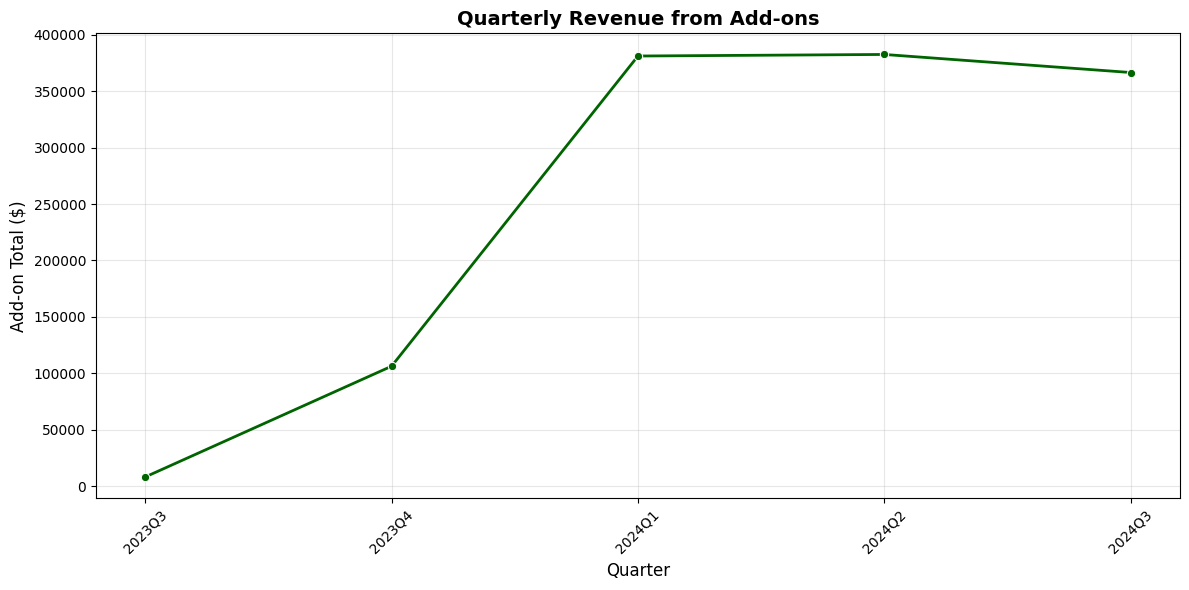

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df['quarter'] = pd.to_datetime(df['Purchase Date']).dt.to_period('Q')
addons_quarter = df.groupby('quarter')['Add-on Total'].sum().reset_index()

addons_quarter['quarter'] = addons_quarter['quarter'].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=addons_quarter,
    x='quarter',
    y='Add-on Total',
    marker='o',
    linewidth=2,
    color='darkgreen'
)
plt.title('Quarterly Revenue from Add-ons', fontsize=14, fontweight='bold')
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Add-on Total ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()